In [1]:
import os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import RidgeClassifier, PassiveAggressiveClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings("ignore")

In [2]:
CSV_PATH = "spam_ham_dataset.csv"

def load_dataset(path):

    if os.path.exists(path):
        print("Loading local file:", path)
        try:
            return pd.read_csv(path, encoding="utf-8")
        except UnicodeDecodeError:
            return pd.read_csv(path, encoding="latin-1")

    try:
        import kagglehub
        folder = kagglehub.dataset_download("venky73/spam-mails-dataset")
        csv = [f for f in os.listdir(folder) if f.endswith(".csv")][0]
        print("Downloaded from Kaggle:", csv)
        return pd.read_csv(os.path.join(folder, csv), encoding="latin-1")
    except Exception as e:
        raise FileNotFoundError(
            "Dataset not found. Download the CSV from Kaggle and set CSV_PATH. Details: " + str(e))

raw = load_dataset(CSV_PATH)
print("Raw shape:", raw.shape)
print("Columns:", list(raw.columns))
raw.head()

Using Colab cache for faster access to the 'spam-mails-dataset' dataset.
Downloaded from Kaggle: spam_ham_dataset.csv
Raw shape: (5171, 4)
Columns: ['Unnamed: 0', 'label', 'text', 'label_num']


,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [3]:
label_candidates = ["label", "category", "v1", "class", "spam", "target"]
text_candidates  = ["text", "message", "v2", "email", "body", "content"]

cols = {c.lower(): c for c in raw.columns}
label_col = next(cols[c] for c in label_candidates if c in cols)
text_col  = next(cols[c] for c in text_candidates  if c in cols)
print("Label column:", label_col, "| Text column:", text_col)

df = raw[[label_col, text_col]].copy()
df.columns = ["label", "message"]

# Convert labels to 'ham' / 'spam'
def fix_label(v):
    s = str(v).strip().lower()
    if s in ("spam", "1", "1.0", "true"):
        return "spam"
    return "ham"
df["label"] = df["label"].apply(fix_label)

# Basic cleaning
df = df.dropna(subset=["label", "message"])
df["message"] = df["message"].astype(str)
df = df.drop_duplicates(subset=["label", "message"]).reset_index(drop=True)

print("\nCleaned shape:", df.shape)
print(df["label"].value_counts())
df.head()

Label column: label | Text column: text

Cleaned shape: (4993, 2)
label
ham     3531
spam    1462
Name: count, dtype: int64


,label,message
0,ham,Subject: enron methanol ; meter # : 988291\r\n...
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see..."
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar..."
3,spam,"Subject: photoshop , windows , office . cheap ..."
4,ham,Subject: re : indian springs\r\nthis deal is t...


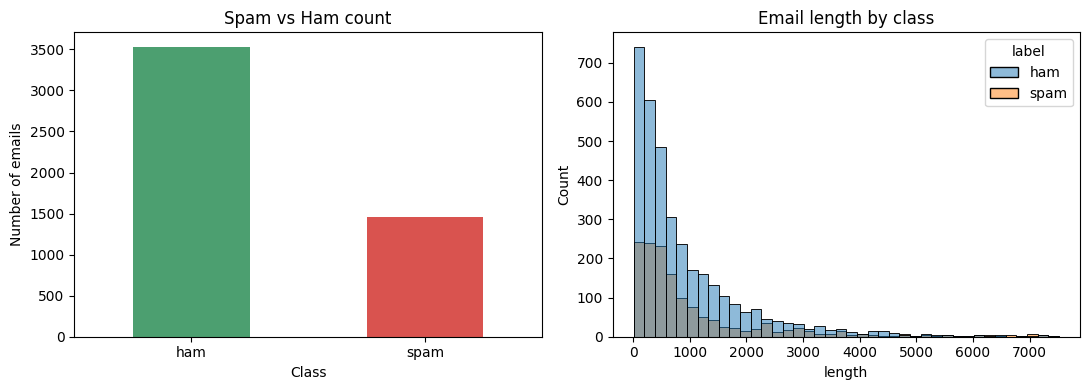

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

df["label"].value_counts().plot(kind="bar", color=["#4C9F70", "#D9534F"], ax=ax[0])
ax[0].set_title("Spam vs Ham count")
ax[0].set_xlabel("Class"); ax[0].set_ylabel("Number of emails")
ax[0].tick_params(axis="x", rotation=0)

df["length"] = df["message"].str.len()
sns.histplot(data=df[df["length"] < df["length"].quantile(0.99)],
             x="length", hue="label", bins=40, ax=ax[1])
ax[1].set_title("Email length by class")

plt.tight_layout(); plt.show()

In [5]:
X = df["message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 3994
Testing samples : 999


In [6]:
models = {
    "Ridge Classifier": RidgeClassifier(),
    "Passive-Aggressive": PassiveAggressiveClassifier(max_iter=1000, random_state=42, tol=1e-3),
    "Complement Naive Bayes": ComplementNB(),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Linear SVM": LinearSVC(random_state=42, max_iter=5000),
}

In [7]:
results = []
trained_models = {}

for name, model in models.items():
    print("Training:", name)

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(lowercase=True, stop_words="english",
                                  ngram_range=(1, 2), max_features=10000,
                                  sublinear_tf=True)),
        ("classifier", model),
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results.append({
        "Algorithm": name,
        "Accuracy (%)":  accuracy_score(y_test, y_pred) * 100,
        "Precision (%)": precision_score(y_test, y_pred, pos_label="spam", zero_division=0) * 100,
        "Recall (%)":    recall_score(y_test, y_pred, pos_label="spam", zero_division=0) * 100,
        "F1-Score (%)":  f1_score(y_test, y_pred, pos_label="spam", zero_division=0) * 100,
    })
    trained_models[name] = pipeline

print("\nDone!")

Training: Ridge Classifier
Training: Passive-Aggressive
Training: Complement Naive Bayes
Training: Extra Trees
Training: Linear SVM

Done!


In [8]:
results_df = (pd.DataFrame(results)
              .sort_values(by="F1-Score (%)", ascending=False)
              .reset_index(drop=True))
results_df.round(2)

,Algorithm,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,Linear SVM,98.90,97.64,98.63,98.13
1,Ridge Classifier,98.80,97.63,98.29,97.96
2,Passive-Aggressive,98.60,97.61,97.61,97.61
3,Extra Trees,97.80,93.29,99.66,96.37
4,Complement Naive Bayes,94.69,85.09,99.32,91.65


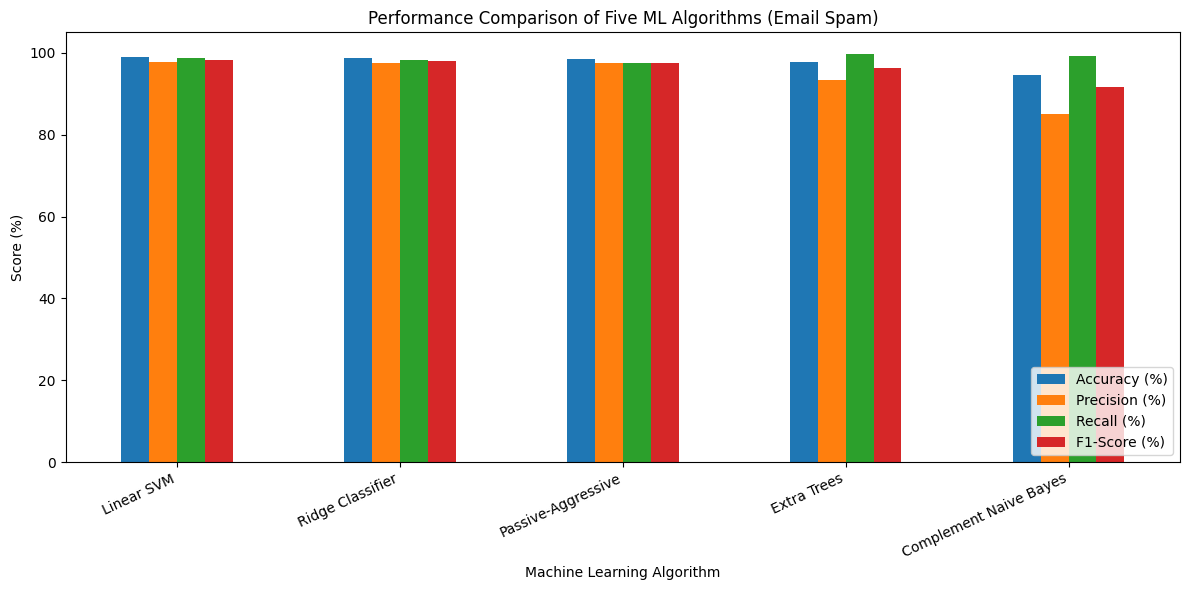

In [9]:
results_df.set_index("Algorithm")[
    ["Accuracy (%)", "Precision (%)", "Recall (%)", "F1-Score (%)"]
].plot(kind="bar", figsize=(12, 6))

plt.title("Performance Comparison of Five ML Algorithms (Email Spam)")
plt.ylabel("Score (%)")
plt.xlabel("Machine Learning Algorithm")
plt.ylim(0, 105)
plt.xticks(rotation=25, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [10]:
best_model_name = results_df.iloc[0]["Algorithm"]
best_model = trained_models[best_model_name]

print("Best Algorithm :", best_model_name)
print("Spam F1-Score  :", round(results_df.iloc[0]["F1-Score (%)"], 2), "%")
print("Accuracy       :", round(results_df.iloc[0]["Accuracy (%)"], 2), "%")

Best Algorithm : Linear SVM
Spam F1-Score  : 98.13 %
Accuracy       : 98.9 %


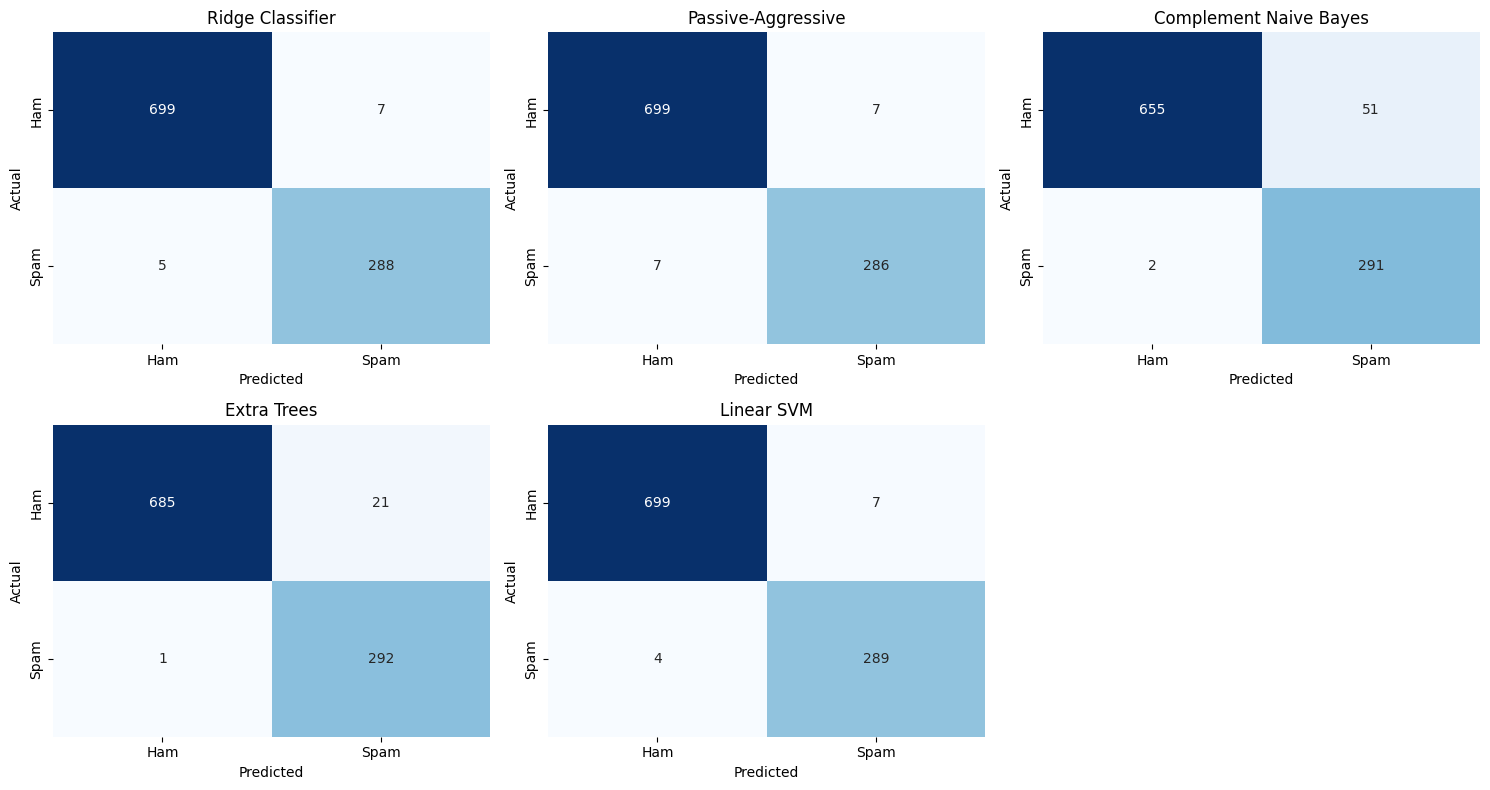

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, (name, pipe) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test), labels=["ham", "spam"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
    ax.set_title(name)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

for ax in axes[len(trained_models):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [12]:
best_predictions = best_model.predict(X_test)
print(classification_report(y_test, best_predictions,
                            labels=["ham", "spam"], zero_division=0))

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       706
        spam       0.98      0.99      0.98       293

    accuracy                           0.99       999
   macro avg       0.99      0.99      0.99       999
weighted avg       0.99      0.99      0.99       999



In [13]:
test_messages = [
    "Subject: Congratulations! You have won a free prize. Click here to claim now!",
    "Subject: Meeting tomorrow - hi team, please find the agenda for the project review attached.",
    "Subject: URGENT! Claim your cash reward now! Limited time offer, act fast!",
    "Subject: Assignment notes - could you please send me the notes from today's class?",
]

for msg in test_messages:
    pred = best_model.predict([msg])[0]
    print("Email     :", msg)
    print("Prediction:", "🚨 SPAM" if pred == "spam" else "✅ HAM (NOT SPAM)")
    print()

Email     : Subject: Congratulations! You have won a free prize. Click here to claim now!
Prediction: 🚨 SPAM

Email     : Subject: Meeting tomorrow - hi team, please find the agenda for the project review attached.
Prediction: ✅ HAM (NOT SPAM)

Email     : Subject: URGENT! Claim your cash reward now! Limited time offer, act fast!
Prediction: 🚨 SPAM

Email     : Subject: Assignment notes - could you please send me the notes from today's class?
Prediction: ✅ HAM (NOT SPAM)

